#SOTA: Generative LLaVA-Med


1. GPU Check

In [1]:
import torch
import sys


2. Setup and Installation

In [23]:
!pip install -q -U transformers
!pip install -q -U peft bitsandbytes accelerate datasets
!pip install -q scikit-learn matplotlib

import os
import gc
import json
import pickle
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from google.colab import drive
from transformers import (
    LlavaForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

3. Memory Clean Up

In [3]:
# --- MEMORY CLEANUP ---
gc.collect()
torch.cuda.empty_cache()

4. Drive Mount and Configuration

In [7]:
import shutil
drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/FINAL_ASSESSMENT_WOA7015-main'
SLAKE_BASE = os.path.join(PROJECT_PATH, "data", "SLAKE")
ANNOTATION_DIR = os.path.join(SLAKE_BASE, "annotations")

# CRITICAL: This must be the SAME folder you saved to before
CHECKPOINT_DIR = os.path.join(PROJECT_PATH, "checkpoints")

# Check if checkpoints exist
if not os.path.exists(CHECKPOINT_DIR) or not os.listdir(CHECKPOINT_DIR):
    print("WARNING: No checkpoints found in Drive!")
    print("If you proceed, training will start from ZERO.")
else:
    print(f"✅ Found checkpoints in {CHECKPOINT_DIR}")
    print(f"Contents: {os.listdir(CHECKPOINT_DIR)}")

# Image Copying (Fast)
#DRIVE_IMAGE_DIR = None
#for d in ["imgs", "images", "Images"]:
    #path = os.path.join(SLAKE_BASE, d)
    #if os.path.exists(path):
        #DRIVE_IMAGE_DIR = path
        #break

#LOCAL_IMAGE_DIR = "/content/slake_images_fast"
#if not os.path.exists(LOCAL_IMAGE_DIR) and DRIVE_IMAGE_DIR:
    #print("🚀 Copying images to local disk...")
    #shutil.copytree(DRIVE_IMAGE_DIR, LOCAL_IMAGE_DIR)
IMAGE_DIR = os.path.join(SLAKE_BASE, "imgs")
MODEL_ID = "llava-hf/llava-1.5-7b-hf"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Found checkpoints in /content/drive/MyDrive/FINAL_ASSESSMENT_WOA7015-main/checkpoints
Contents: ['checkpoint-615', 'checkpoint-700']


5. Dataset class (Optimized for Slake)

In [8]:
# Dataset Class
class VQADataset(torch.utils.data.Dataset):
    def __init__(self, data, processor, image_dir):
        self.data = data
        self.processor = processor
        self.image_dir = image_dir
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]
        image_name = item.get('image_name', item.get('img_name'))
        image_path = os.path.join(self.image_dir, image_name)
        try: image = Image.open(image_path).convert("RGB")
        except: image = Image.new('RGB', (224, 224), color='black')

        # We assume train_en.json is clean, but a strip() never hurts
        question = str(item['question']).strip()
        answer = str(item['answer']).strip()

        text = f"USER: <image>\n{question} Answer briefly.\nASSISTANT: {answer}"
        inputs = self.processor(text=text, images=image, return_tensors="pt", padding="max_length", truncation=True, max_length=768)
        return {
            "input_ids": inputs.input_ids.squeeze(0),
            "attention_mask": inputs.attention_mask.squeeze(0),
            "pixel_values": inputs.pixel_values.squeeze(0),
            "labels": inputs.input_ids.squeeze(0)
        }

6. Load Data

In [25]:
def load_json(path):
    print(f"Loading {path}...")
    with open(path, 'r') as f: return json.load(f)

# Load Data
print("Loading Datasets...")
train_data = load_json(os.path.join(ANNOTATION_DIR, "train_en.json"))
test_data = load_json(os.path.join(ANNOTATION_DIR, "test_en.json"))

print(f"Clean Training Data: {len(train_data)}")
print(f"Clean Test Data:     {len(test_data)}")

Loading Datasets...
Loading /content/drive/MyDrive/FINAL_ASSESSMENT_WOA7015-main/data/SLAKE/annotations/train_en.json...
Loading /content/drive/MyDrive/FINAL_ASSESSMENT_WOA7015-main/data/SLAKE/annotations/test_en.json...
Clean Training Data: 4919
Clean Test Data:     1061


7. Model Setup

In [10]:
bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16)
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = LlavaForConditionalGeneration.from_pretrained(MODEL_ID, quantization_config=bnb_config, device_map="auto")
peft_config = LoraConfig(r=16, lora_alpha=32, target_modules=["q_proj", "v_proj"], lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")
model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, peft_config)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

8. Training Loop

In [27]:
train_dataset = VQADataset(train_data, processor, IMAGE_DIR)

def collate_fn(batch):
    return {
        'input_ids': torch.stack([x['input_ids'] for x in batch]),
        'attention_mask': torch.stack([x['attention_mask'] for x in batch]),
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.stack([x['labels'] for x in batch])
    }

args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,      # Point to Drive Checkpoints
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,

    # === CRITICAL CHANGE HERE ===
    num_train_epochs=10,
    # ============================

    learning_rate=2e-4,
    fp16=True,
    logging_steps=50,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    report_to="none"
)

trainer = Trainer(model=model, args=args, train_dataset=train_dataset, data_collator=collate_fn)

print("Resuming Training...")

# --- SMART AUTO-RESUME LOGIC ---
# Find the latest checkpoint folder automatically (e.g., "checkpoint-615")
checkpoints = [d for d in os.listdir(CHECKPOINT_DIR) if d.startswith("checkpoint-")]
if checkpoints:
    # Sort to find the highest number (615 > 600)
    checkpoints.sort(key=lambda x: int(x.split('-')[1]))
    latest_checkpoint = checkpoints[-1]
    latest_checkpoint_path = os.path.join(CHECKPOINT_DIR, latest_checkpoint)

    print(f"✅ Auto-detected latest checkpoint: {latest_checkpoint}")
    print("Resuming training from there...")
    trainer.train(resume_from_checkpoint=latest_checkpoint_path)
else:
    print("No checkpoints found. Starting fresh from Epoch 0.")
    trainer.train()

Resuming Training...
✅ Auto-detected latest checkpoint: checkpoint-4305
Resuming training from there...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
4350,5.515515
4400,5.514433
4450,5.506065
4500,5.513029
4550,5.511005
4600,5.513094
4650,5.518242
4700,5.507910
4750,5.515911
4800,5.519506


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

9. Evaluation

In [28]:
print("Running Evaluation on Test Set...")
results = []
correct = 0

# Using tqdm for progress bar
for item in tqdm(test_data):
    image_name = item.get('image_name', item.get('img_name'))
    img_path = os.path.join(IMAGE_DIR, image_name)

    # Cleaning ground truth similarly
    gt_answer = str(item['answer']).replace('</s>', '').lower().strip()
    clean_question = str(item['question']).replace('</s>', '').strip()

    prompt = f"USER: <image>\n{clean_question} Answer briefly.\nASSISTANT:"

    try:
        image = Image.open(img_path).convert("RGB")
        inputs = processor(text=prompt, images=image, return_tensors="pt").to("cuda")

        with torch.inference_mode():
            out = model.generate(**inputs, max_new_tokens=20, do_sample=False)

        pred = processor.decode(out[0], skip_special_tokens=True).split("ASSISTANT:")[-1].strip().lower()

        # Accuracy Check: Exact match or substring (generative models can be chatty)
        is_correct = (gt_answer == pred) or (gt_answer in pred)
        if is_correct: correct += 1

        results.append({
            "image": image_name,
            "question": clean_question,
            "truth": gt_answer,
            "pred": pred,
            "correct": is_correct
        })

    except Exception as e:
        print(f"Error on {image_name}: {e}")

# Save Results
df = pd.DataFrame(results)
if len(test_data) > 0:
    acc = (correct / len(test_data)) * 100
    print(f"Final Accuracy: {acc:.2f}%")
    df.to_csv("llava_med_slake_results.csv", index=False)
else:
    print("Skipping accuracy calculation (no test data).")

Running Evaluation on Test Set...


  0%|          | 0/1061 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Final Accuracy: 40.53%


10. Plotting Graph

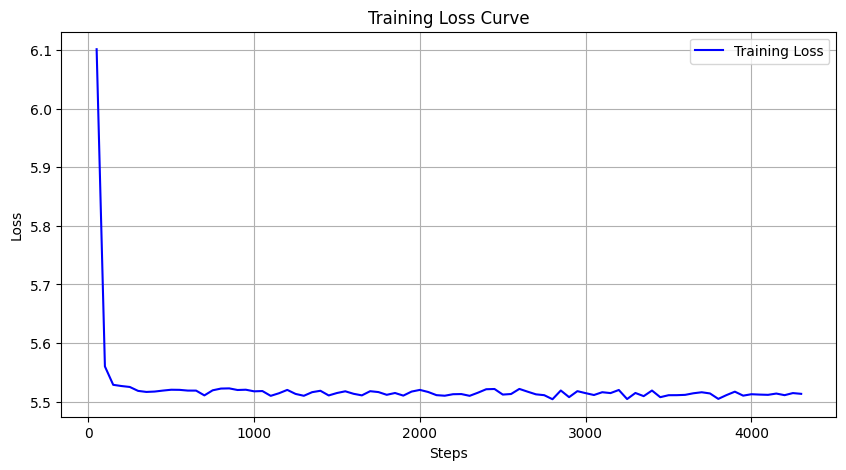

Graph saved as training_loss_curve.png


In [15]:
import matplotlib.pyplot as plt

# 1. Plot Training Loss (Learning Curve)
# We extract the training history stored in the trainer object
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
steps = [x['step'] for x in history if 'loss' in x]

if train_loss:
    plt.figure(figsize=(10, 5))
    plt.plot(steps, train_loss, label='Training Loss', color='blue')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training Loss Curve')
    plt.legend()
    plt.grid(True)
    plt.savefig('training_loss_curve.png') # Save for report
    plt.show()
    print("Graph saved as training_loss_curve.png")


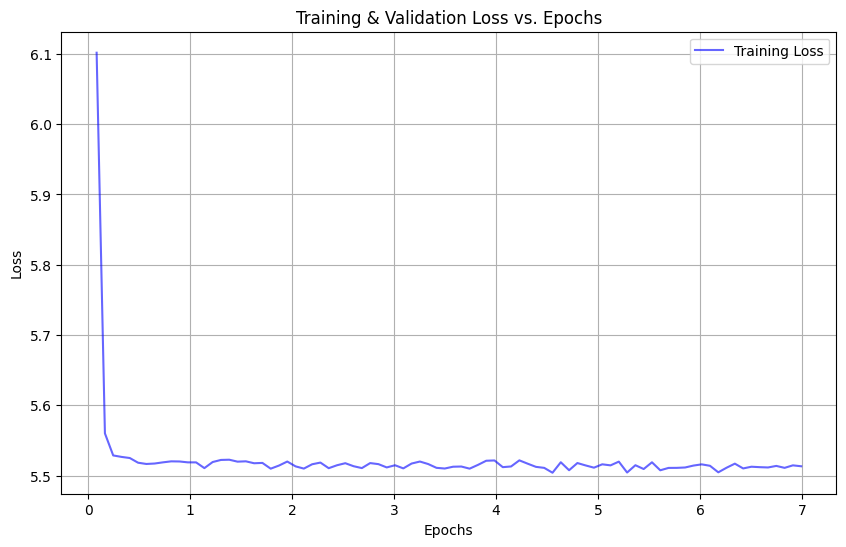

Graph saved as loss_vs_epoch_curve.png


In [18]:
# Extract history
history = trainer.state.log_history

# Extract Training Loss
train_loss = [x['loss'] for x in history if 'loss' in x]
train_epochs = [x['epoch'] for x in history if 'loss' in x]

# Extract Validation Loss
val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
val_epochs = [x['epoch'] for x in history if 'eval_loss' in x]

if train_loss:
    plt.figure(figsize=(10, 6))

    # Plot Training Loss
    plt.plot(train_epochs, train_loss, label='Training Loss', color='blue', alpha=0.6)

    # Plot Validation Loss (if available)
    if val_loss:
        plt.plot(val_epochs, val_loss, label='Validation Loss', color='red', marker='o', linestyle='--')

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss vs. Epochs')
    plt.legend()
    plt.grid(True)

    plt.savefig('loss_vs_epoch_curve.png')
    plt.show()
    print("Graph saved as loss_vs_epoch_curve.png")
else:
    print("No loss history found to plot.")

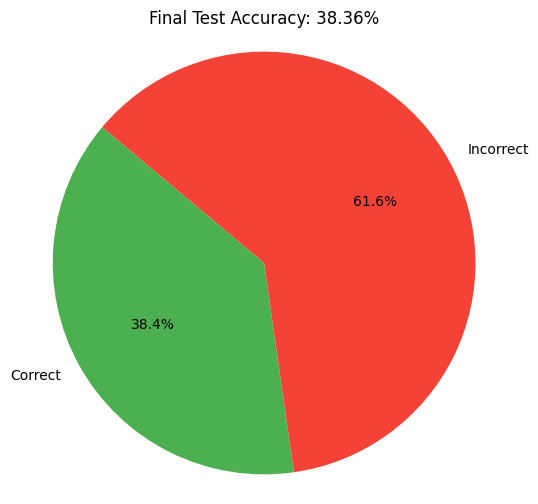

Graph saved as test_accuracy_chart.png


In [16]:
# 2. Plot Test Accuracy (Pie Chart)
plt.figure(figsize=(6, 6))
labels = ['Correct', 'Incorrect']
sizes = [correct, len(test_data) - correct]
colors = ['#4CAF50', '#F44336'] # Green for correct, Red for incorrect
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title(f'Final Test Accuracy: {acc:.2f}%')
plt.axis('equal')
plt.savefig('test_accuracy_chart.png') # Save for report
plt.show()
print("Graph saved as test_accuracy_chart.png")

10. Save Model

In [ ]:
# Method 1: Hugging Face Standard (Preferred for LoRA)
model.save_pretrained("./llava_med_final_model")
processor.save_pretrained("./llava_med_final_model")
print("Model adapters saved to ./llava_med_final_model")

11. GUI